<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW4_Q4</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 🌳 Decision Tree Construction (ID3 Algorithm)
### Manual Implementation from Scratch & Library Comparison

> **University:** University of Tehran
> **Course:** Machine Learning
> **Assignment:** Homework 4 - Question 4
> **Topic:** Decision Trees, Entropy, ID3 vs. CART

---

## 📝 Problem Statement
The objective is to build a **Decision Tree** classifier to predict whether a customer will wait for a table at a restaurant based on various situational features (e.g., `Alternate`, `Hungry`, `Price`, `Rain`, etc.).

**Key Objectives:**
1.  **Mathematical Implementation:** Implement **Entropy** and **Information Gain** functions from scratch to determine the optimal splitting features.
2.  **Recursive Tree Building:** Develop the **ID3 Algorithm** logic to construct the tree structure node by node.
3.  **Visualization:** Generate a visual representation of the decision tree using `Graphviz`.
4.  **Validation & Comparison:**
    * Implement the same classification task using `sklearn.tree.DecisionTreeClassifier`.
    * **Important Note:** Compare the manually generated tree (ID3, Multi-way splits) with the Sklearn generated tree (CART, Binary splits). Due to algorithmic differences, the visual structures will differ, but the classification logic serves as a validation benchmark.

---

### Imports

In [ ]:
import pandas as pd
import numpy as np
from graphviz import Digraph
from IPython.display import Image, display

## a)Implementation without using ready-made libraries

### Load the Data and Data Overview

In [73]:
data_dict = {
    "Alt": ["Yes", "Yes", "No", "Yes", "Yes", "No", "No", "No", "No", "Yes", "No", "Yes"],
    "Bar": ["No", "No", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes", "No", "Yes"],
    "Fri": ["No", "No", "No", "Yes", "Yes", "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "Hun": ["Yes", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes"],
    "Pat": ["Some", "Full", "Some", "Full", "Full", "Some", "None", "Some", "Full", "Full", "None", "Full"],
    "Price": ["$$$", "$", "$", "$", "$$$", "$$", "$", "$$", "$", "$$$", "$", "$"],
    "Rain": ["No", "No", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes", "No", "No", "No"],
    "Res": ["Yes", "No", "No", "No", "Yes", "Yes", "No", "Yes", "No", "Yes", "No", "No"],
    "Type": ["French", "Thai", "Burger", "Thai", "French", "Italian", "Burger", "Thai", "Burger", "Italian", "Thai", "Burger"],
    "Est": ["0-10", "30-60", "0-10", "10-30", ">60", "0-10", "0-10", "0-10", ">60", "10-30", "0-10", "30-60"]
}
data = pd.DataFrame(data_dict)
labels = pd.Series(["Yes", "No", "Yes", "Yes", "No", "Yes", "No", "Yes", "No", "No", "No", "Yes"])
data

,Alt,Bar,Fri,Hun,Pat,Price,Rain,Res,Type,Est
0,Yes,No,No,Yes,Some,$$$,No,Yes,French,0-10
1,Yes,No,No,Yes,Full,$,No,No,Thai,30-60
2,No,Yes,No,No,Some,$,No,No,Burger,0-10
3,Yes,No,Yes,Yes,Full,$,Yes,No,Thai,10-30
4,Yes,No,Yes,No,Full,$$$,No,Yes,French,>60
5,No,Yes,No,Yes,Some,$$,Yes,Yes,Italian,0-10
6,No,Yes,No,No,None,$,Yes,No,Burger,0-10
7,No,No,No,Yes,Some,$$,Yes,Yes,Thai,0-10
8,No,Yes,Yes,No,Full,$,Yes,No,Burger,>60
9,Yes,Yes,Yes,Yes,Full,$$$,No,Yes,Italian,10-30


### entropy function :

In [74]:
def calculate_entropy(data):
    total = len(data)
    counts = data.value_counts()
    probabilities = counts / total
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy


### informatio gain function :

In [75]:
def information_gain(data, target, feature):
    H_Y = calculate_entropy(target)
    total = len(data)
    H_Y_Xi = 0 #mutual information
    for value in data[feature].unique():
        subset = target[data[feature] == value]
        H_Y_Xi += (len(subset) / total) * calculate_entropy(subset)
    return H_Y - H_Y_Xi


### building tree:

In [76]:
def build_decision_tree(data, target, feature_names):
    
    if len(target.unique()) == 1:
        return target.iloc[0]
    
    if len(feature_names) == 0:
        return target.mode()[0]

    best_feature = None
    best_gain = 0
    for feature in feature_names:
        gain = information_gain(data, target, feature)
        if gain > best_gain:
            best_gain = gain
            best_feature = feature

    tree = {"feature": best_feature, "branches": {}}
    feature_names = [f for f in feature_names if f != best_feature]
    for value in data[best_feature].unique():
        subset_data = data[data[best_feature] == value]
        subset_target = target[data[best_feature] == value]
        tree["branches"][value] = build_decision_tree(subset_data, subset_target, feature_names)

    return tree

### printing tree

In [77]:

def add_nodes(tree, parent, branch_label, graph):
    if isinstance(tree, dict) and 'feature' in tree:
        feature = tree['feature']
        graph.node(feature) 
        if parent:
            graph.edge(parent, feature, label=branch_label)  
        if 'branches' in tree:
            for branch, sub_tree in tree['branches'].items():
                if isinstance(sub_tree, dict):
                    add_nodes(sub_tree, feature, branch, graph)
                else:
                    leaf = sub_tree
                    leaf_name = f"{feature}_{branch}_{leaf}"  
                    graph.node(leaf_name, label=leaf) 
                    graph.edge(feature, leaf_name, label=branch)  

### Implementation

In [79]:

feature_names = list(data.columns)
tree = build_decision_tree(data, labels, feature_names)
tree
dot = Digraph()
add_nodes(tree, None, '', dot)

dot.render('decision_tree', format='png')


'decision_tree.png'

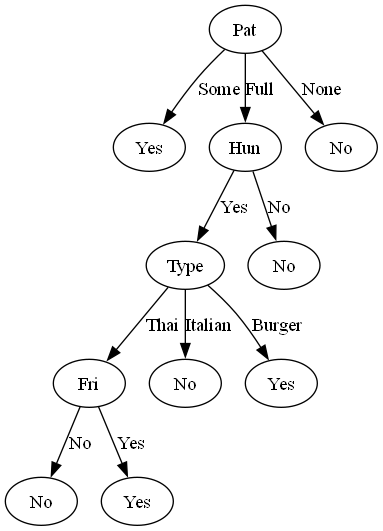

In [3]:
display(Image(filename='decision_tree.png'))

## b)Implementation using ready-made libraries

### Imports

In [80]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns

### data

In [81]:
data

,Alt,Bar,Fri,Hun,Pat,Price,Rain,Res,Type,Est
0,Yes,No,No,Yes,Some,$$$,No,Yes,French,0-10
1,Yes,No,No,Yes,Full,$,No,No,Thai,30-60
2,No,Yes,No,No,Some,$,No,No,Burger,0-10
3,Yes,No,Yes,Yes,Full,$,Yes,No,Thai,10-30
4,Yes,No,Yes,No,Full,$$$,No,Yes,French,>60
5,No,Yes,No,Yes,Some,$$,Yes,Yes,Italian,0-10
6,No,Yes,No,No,None,$,Yes,No,Burger,0-10
7,No,No,No,Yes,Some,$$,Yes,Yes,Thai,0-10
8,No,Yes,Yes,No,Full,$,Yes,No,Burger,>60
9,Yes,Yes,Yes,Yes,Full,$$$,No,Yes,Italian,10-30


### Implementation

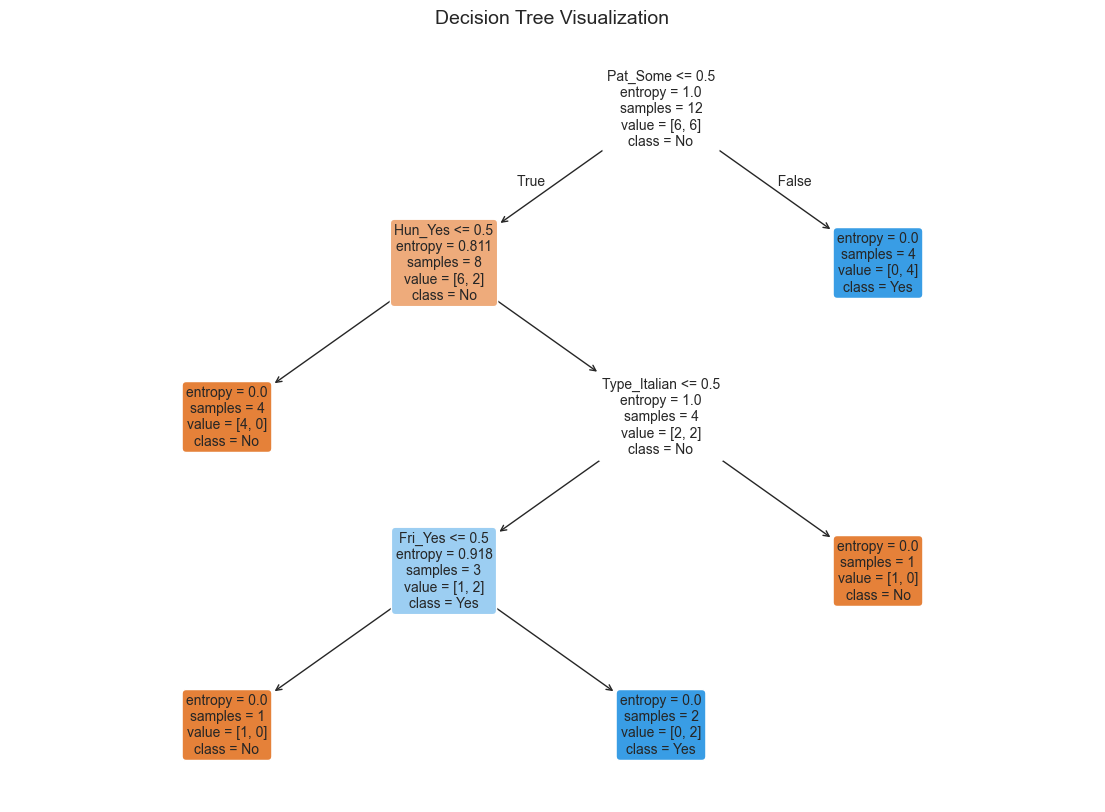

In [82]:
sns.set(style="whitegrid")

ohe = OneHotEncoder()
data_encoded = pd.DataFrame(ohe.fit_transform(data).toarray(), columns=ohe.get_feature_names_out())

clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(data_encoded, labels)

fig, ax = plt.subplots(figsize=(14, 10))
plot_tree(clf, feature_names=list(data_encoded.columns), class_names=["No", "Yes"], filled=True, rounded=True, fontsize=10, ax=ax)
plt.title("Decision Tree Visualization", fontsize=14)
plt.show()